In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


###Image Coloring

In [ ]:
!pip install opencv-python opencv-python-headless

In [ ]:
import urllib.request
import os

# Download prototxt
urllib.request.urlretrieve(
    "https://storage.openvinotoolkit.org/repositories/datumaro/models/colorization/colorization_deploy_v2.prototxt",
    "colorization_deploy_v2.prototxt"
)

# Download pts_in_hull.npy
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/richzhang/colorization/caffe/colorization/resources/pts_in_hull.npy",
    "pts_in_hull.npy"
)

# The caffemodel is large (~130MB), download separately
urllib.request.urlretrieve(
    "https://storage.openvinotoolkit.org/repositories/datumaro/models/colorization/colorization_release_v2.caffemodel",
    "colorization_release_v2.caffemodel"
)

print("All files downloaded!")

All files downloaded!


In [ ]:
import numpy as np
import cv2
import os
import argparse
import matplotlib.pyplot as plt

proto = '/content/colorization_deploy_v2.prototxt'
model = '/content/colorization_release_v2.caffemodel'
pts = '/content/pts_in_hull.npy'

net = cv2.dnn.readNetFromCaffe(proto, model)
pts = np.load(pts)


pts = pts.transpose().reshape(2, 313, 1, 1)

class8 = net.getLayerId("class8_ab")
conv8 = net.getLayerId("conv8_313_rh")

net.getLayer(class8).blobs = [pts.astype("float32")]
net.getLayer(conv8).blobs = [np.full([1, 313], 2.606, dtype="float32")]


def colorize_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_norm = img.astype("float32") / 255.0
    lab = cv2.cvtColor(img_norm, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0]

    # Resize for model input
    L_resized = cv2.resize(L, (224, 224))
    L_resized -= 50  # mean-centering

    net.setInput(cv2.dnn.blobFromImage(L_resized))
    ab = net.forward()[0, :, :, :].transpose((1, 2, 0))

    # Resize back to original size
    ab = cv2.resize(ab, (img.shape[1], img.shape[0]))

    # Combine L and ab
    lab_out = np.concatenate((L[:, :, np.newaxis], ab), axis=2)

    rgb_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)
    rgb_out = np.clip(rgb_out, 0, 1)

    return img, rgb_out

In [ ]:
def preprocess_fer_image(gray_img):
    gray_img = cv2.resize(gray_img, (224, 224))
    rgb_img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)
    return rgb_img

In [ ]:
import os
import kagglehub
import glob

# Find any image in the dataset
image_files = glob.glob(os.path.join(path, '**/*.png'), recursive=True) + \
              glob.glob(os.path.join(path, '**/*.jpg'), recursive=True)

print(f"Found {len(image_files)} images")
print("Sample:", image_files[:3])

# Use the first one
img_path = image_files[0]
gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

assert gray is not None, f"Failed to load image from: {img_path}"
print(f"Loaded image shape: {gray.shape}")

Found 35887 images
Sample: ['/kaggle/input/fer2013/test/surprise/PublicTest_78686873.jpg', '/kaggle/input/fer2013/test/surprise/PrivateTest_58522921.jpg', '/kaggle/input/fer2013/test/surprise/PrivateTest_83796714.jpg']
Loaded image shape: (48, 48)


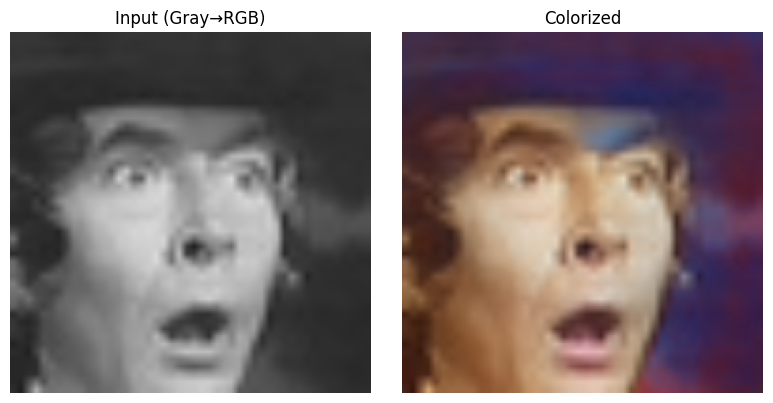

In [ ]:
rgb_input = preprocess_fer_image(gray)
cv2.imwrite('/content/temp.png', rgb_input)
original, colorized = colorize_image('/content/temp.png')

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Input (Gray→RGB)")
plt.imshow(original)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Colorized")
plt.imshow(colorized)
plt.axis("off")
plt.tight_layout()
plt.show()

###Live Facial Expression Recognition

In [ ]:
from IPython.display import HTML, display

html_code = """
<div style="position:relative;display:inline-block">
  <video id="v" width="640" height="480" autoplay muted playsinline
    style="display:block;border-radius:8px;background:#000"></video>
  <canvas id="c" width="640" height="480"
    style="position:absolute;top:0;left:0;pointer-events:none"></canvas>
</div>
<div id="log" style="font-family:monospace;font-size:15px;margin-top:10px;min-height:24px">Loading models...</div>

<script src="https://cdn.jsdelivr.net/npm/face-api.js@0.22.2/dist/face-api.min.js"></script>
<script>
const MODEL_URL = 'https://raw.githubusercontent.com/justadudewhohacks/face-api.js/master/weights';

async function init() {
  // Load the two required models
  await Promise.all([
    faceapi.nets.tinyFaceDetector.loadFromUri(MODEL_URL),
    faceapi.nets.faceExpressionNet.loadFromUri(MODEL_URL)
  ]);

  document.getElementById('log').textContent = 'Models loaded. Starting webcam...';

  // Request webcam access
  const stream = await navigator.mediaDevices.getUserMedia({ video: true });
  const video = document.getElementById('v');
  const canvas = document.getElementById('c');
  video.srcObject = stream;

  video.addEventListener('play', () => {
    document.getElementById('log').textContent = 'Detecting...';

    setInterval(async () => {
      // Detect all faces + their expressions
      const detections = await faceapi
        .detectAllFaces(video, new faceapi.TinyFaceDetectorOptions())
        .withFaceExpressions();

      // Match canvas size to the displayed video
      const dims = faceapi.matchDimensions(canvas, video, true);
      const resized = faceapi.resizeResults(detections, dims);

      // Clear and redraw overlays
      const ctx = canvas.getContext('2d');
      ctx.clearRect(0, 0, canvas.width, canvas.height);
      faceapi.draw.drawDetections(canvas, resized);           //bounding box
      faceapi.draw.drawFaceExpressions(canvas, resized, 0.05); //expression bars (min threshold 5%)

      // Show top-3 emotions as text below the video
      if (resized.length > 0) {
        const expr = resized[0].expressions;
        const top3 = Object.entries(expr)
          .sort((a, b) => b[1] - a[1])
          .slice(0, 3);
        document.getElementById('log').innerHTML = top3
          .map(([e, v]) => `<b>${e}</b>: ${(v * 100).toFixed(1)}%`)
          .join(' &nbsp;&nbsp;|&nbsp;&nbsp; ');
      } else {
        document.getElementById('log').textContent = 'No face detected';
      }

    }, 300); // run every 300ms (~3fps)
  });
}

init().catch(err => {
  document.getElementById('log').textContent = 'Error: ' + err.message;
  console.error(err);
});
</script>
"""

display(HTML(html_code))